# Stress-Predict-Dataset (2022)

ref) https://github.com/italha-d/Stress-Predict-Dataset/tree/main

In [8]:
import os
import glob
import pandas as pd
import numpy as np

# =========================================================
# 설정
# =========================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/Stress-Predict-Dataset/Raw_data"

# =========================================================
# Empatica signal csv 로더
# BVP, EDA
# 형식:
# 1행: start timestamp
# 2행: sampling rate
# 3행~: signal values
# =========================================================
def load_empatica_signal_csv(file_path, signal_name):
    raw = pd.read_csv(file_path, header=None)

    start_ts = float(raw.iloc[0, 0])
    fs = float(raw.iloc[1, 0])

    values = raw.iloc[2:, 0].astype(float).reset_index(drop=True)
    timestamps = start_ts + np.arange(len(values)) / fs

    df = pd.DataFrame({
        "timestamp": timestamps,
        signal_name: values
    })

    return df, start_ts, fs


# =========================================================
# IBI 로더 (실제 파일 형식 반영)
# 형식:
# 1행: "start_timestamp, IBI"
# 2행~: "relative_time_sec, ibi_sec"
# =========================================================
def load_ibi_csv(file_path):
    raw = pd.read_csv(file_path, header=None)

    # 첫 행 첫 번째 값 = 시작 timestamp
    start_ts = float(str(raw.iloc[0, 0]).strip())

    # 첫 행 제외 후 데이터
    data = raw.iloc[1:, :2].copy()
    data.columns = ["relative_time", "ibi"]
    data = data.dropna()

    data["relative_time"] = data["relative_time"].astype(float)
    data["ibi"] = data["ibi"].astype(float)

    # absolute timestamp
    data["timestamp"] = start_ts + data["relative_time"]

    return data[["timestamp", "relative_time", "ibi"]], start_ts


# =========================================================
# tags 로더
# 형식:
# 각 행 = 버튼 누른 시간(timestamp)
# =========================================================
def load_tags_csv(file_path):
    raw = pd.read_csv(file_path, header=None)

    tags = raw.iloc[:, 0].dropna().astype(float).reset_index(drop=True)

    df = pd.DataFrame({
        "tag_idx": np.arange(len(tags)),
        "timestamp": tags
    })

    return df


# =========================================================
# subject 하나 로드
# =========================================================
def load_subject_data(subject_dir):
    subject_id = os.path.basename(subject_dir)

    bvp_path = os.path.join(subject_dir, "BVP.csv")
    eda_path = os.path.join(subject_dir, "EDA.csv")
    ibi_path = os.path.join(subject_dir, "IBI.csv")
    tags_path = os.path.join(subject_dir, f"tags_{subject_id}.csv")

    subject_data = {
        "subject_id": subject_id,
        "bvp": None,
        "eda": None,
        "ibi": None,
        "tags": None,
        "meta": {}
    }

    if os.path.exists(bvp_path):
        bvp_df, bvp_start, bvp_fs = load_empatica_signal_csv(bvp_path, "bvp")
        subject_data["bvp"] = bvp_df
        subject_data["meta"]["bvp_start"] = bvp_start
        subject_data["meta"]["bvp_fs"] = bvp_fs

    if os.path.exists(eda_path):
        eda_df, eda_start, eda_fs = load_empatica_signal_csv(eda_path, "eda")
        subject_data["eda"] = eda_df
        subject_data["meta"]["eda_start"] = eda_start
        subject_data["meta"]["eda_fs"] = eda_fs

    if os.path.exists(ibi_path):
        ibi_df, ibi_start = load_ibi_csv(ibi_path)
        subject_data["ibi"] = ibi_df
        subject_data["meta"]["ibi_start"] = ibi_start

    if os.path.exists(tags_path):
        tags_df = load_tags_csv(tags_path)
        subject_data["tags"] = tags_df

    return subject_data


# =========================================================
# 전체 subject 로드
# =========================================================
def load_all_subjects(root_dir):
    subject_dirs = sorted(
        [d for d in glob.glob(os.path.join(root_dir, "S*")) if os.path.isdir(d)]
    )

    all_data = {}

    for subject_dir in subject_dirs:
        subject_id = os.path.basename(subject_dir)
        try:
            all_data[subject_id] = load_subject_data(subject_dir)
            print(f"[OK] {subject_id} loaded")
        except Exception as e:
            print(f"[ERROR] {subject_id}: {e}")

    return all_data


# =========================================================
# 실행 예시
# =========================================================
all_data = load_all_subjects(ROOT_DIR)

print("\n총 subject 수:", len(all_data))

s01 = all_data["S01"]

print("\n[S01 meta]")
print(s01["meta"])

print("\n[S01 BVP head]")
print(s01["bvp"].head())

print("\n[S01 EDA head]")
print(s01["eda"].head())

print("\n[S01 IBI head]")
print(s01["ibi"].head())

print("\n[S01 tags]")
print(s01["tags"])

[OK] S01 loaded
[OK] S02 loaded
[OK] S03 loaded
[OK] S04 loaded
[OK] S05 loaded
[OK] S06 loaded
[OK] S07 loaded
[OK] S08 loaded
[OK] S09 loaded
[OK] S10 loaded
[OK] S11 loaded
[OK] S12 loaded
[OK] S13 loaded
[OK] S14 loaded
[OK] S15 loaded
[OK] S16 loaded
[OK] S17 loaded
[OK] S18 loaded
[OK] S19 loaded
[OK] S20 loaded
[OK] S21 loaded
[OK] S22 loaded
[OK] S23 loaded
[OK] S24 loaded
[OK] S25 loaded
[OK] S26 loaded
[OK] S27 loaded
[OK] S28 loaded
[OK] S29 loaded
[OK] S30 loaded
[OK] S31 loaded
[OK] S32 loaded
[OK] S33 loaded
[OK] S34 loaded
[OK] S35 loaded

총 subject 수: 35

[S01 meta]
{'bvp_start': 1644226061.0, 'bvp_fs': 64.0, 'eda_start': 1644226061.0, 'eda_fs': 4.0, 'ibi_start': 1644226061.0}

[S01 BVP head]
      timestamp  bvp
0  1.644226e+09  0.0
1  1.644226e+09  0.0
2  1.644226e+09  0.0
3  1.644226e+09  0.0
4  1.644226e+09  0.0

[S01 EDA head]
      timestamp       eda
0  1.644226e+09  0.000000
1  1.644226e+09  0.112750
2  1.644226e+09  0.166563
3  1.644226e+09  0.167844
4  1.64422

| 구간 | label |
| --- | --- |
| Stroop / TSST / Hyperventilation | **Stress (1)** |
| Rest / Baseline Reading / Questionnaire | **Normal (0)** |

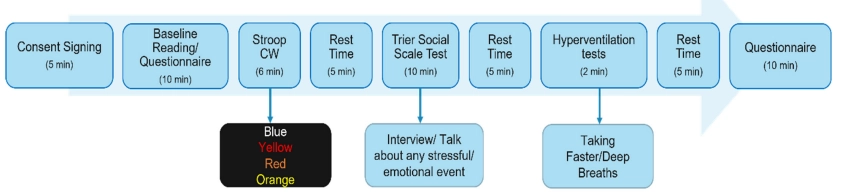

- t0~t1: Baseline
- t1~t2: Stroop
- t2~t3: Rest1
- t3~t4: TSST
- t4~t5: Rest2
- t5~t6: Hyperventilation
- t6~t7: Rest3
- t7~t8: Questionnaire
- t8~t9: extra/end 구간이면 제외 또는 normal로 처리

In [7]:
s01 = all_data["S01"]

# 1) BVP / EDA timestamp 간격 확인
print("BVP dt:", np.unique(np.round(np.diff(s01["bvp"]["timestamp"].head(20)), 6)))
print("EDA dt:", np.unique(np.round(np.diff(s01["eda"]["timestamp"].head(20)), 6)))

# 2) IBI 기본 확인
print("\nIBI relative_time diff:")
print(np.round(np.diff(s01["ibi"]["relative_time"].head(20)), 6))

print("\nIBI value summary:")
print(s01["ibi"]["ibi"].describe())

# 3) timestamp 계산 검증
print("\nCheck IBI timestamp reconstruction:")
print((s01["ibi"]["timestamp"] - s01["meta"]["ibi_start"]).head())
print(s01["ibi"]["relative_time"].head())

BVP dt: [0.015625]
EDA dt: [0.25]

IBI relative_time diff:
[0.859375 0.953125 0.890625 0.859375 0.8125   0.796875 0.734375 0.734375
 0.78125  0.84375  0.859375 0.953125 1.       0.9375   0.953125 1.
 1.       1.       0.9375  ]

IBI value summary:
count    1260.000000
mean        0.914745
std         0.085845
min         0.593750
25%         0.859375
50%         0.921875
75%         0.984375
max         1.328125
Name: ibi, dtype: float64

Check IBI timestamp reconstruction:
1    35.484375
2    36.343750
3    37.296875
4    38.187500
5    39.046875
Name: timestamp, dtype: float64
1    35.484375
2    36.343750
3    37.296875
4    38.187500
5    39.046875
Name: relative_time, dtype: float64



[S01] intervals
   interval_idx             phase             start               end  label  \
0             0          Baseline 1644226140.000000 1644226435.000000      0   
1             1            Stroop 1644226435.000000 1644226707.000000      1   
2             2             Rest1 1644226707.000000 1644227092.000000      0   
3             3              TSST 1644227092.000000 1644227657.000000      1   
4             4             Rest2 1644227657.000000 1644227991.000000      0   
5             5  Hyperventilation 1644227991.000000 1644228133.000000      1   
6             6             Rest3 1644228133.000000 1644228446.000000      0   
7             7     Questionnaire 1644228446.000000 1644228684.000000      0   

   duration_sec  
0    295.000000  
1    272.000000  
2    385.000000  
3    565.000000  
4    334.000000  
5    142.000000  
6    313.000000  
7    238.000000  


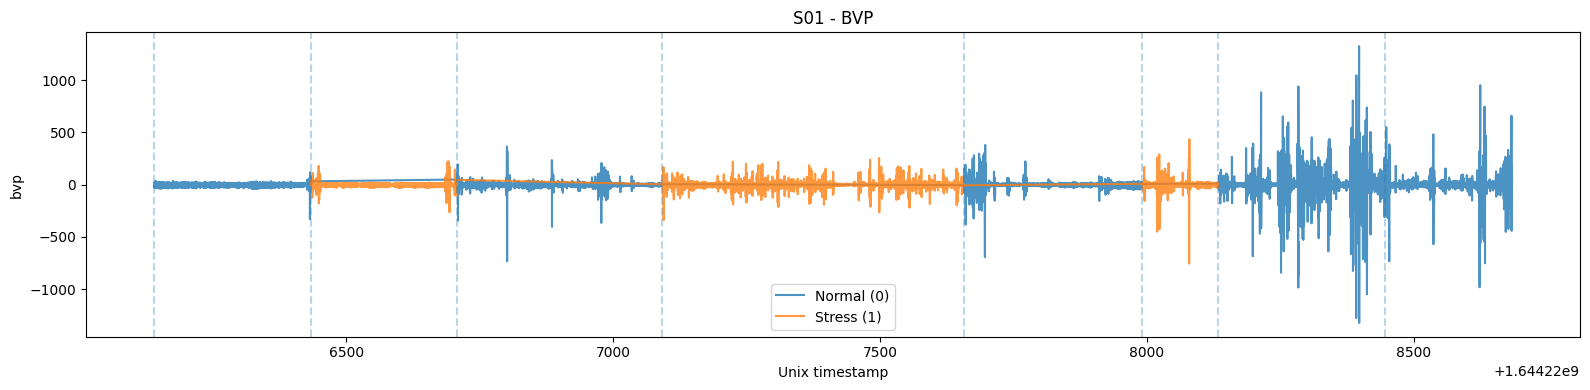

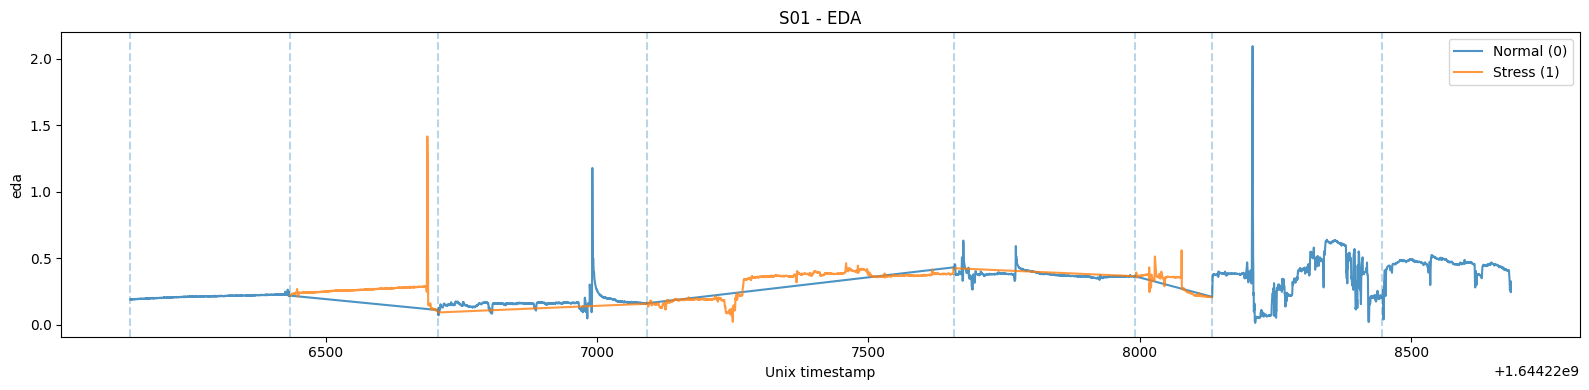

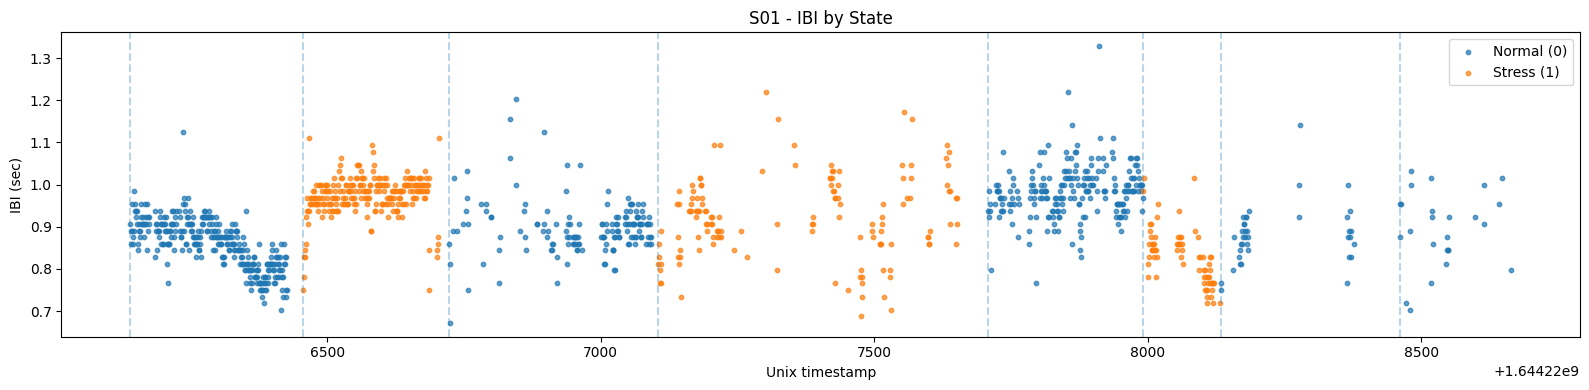


[S03] intervals
   interval_idx             phase             start               end  label  \
0             0          Baseline 1644231934.030000 1644232209.770000      0   
1             1            Stroop 1644232209.770000 1644232484.030000      1   
2             2             Rest1 1644232484.030000 1644233026.120000      0   
3             3              TSST 1644233026.120000 1644233339.390000      1   
4             4             Rest2 1644233339.390000 1644233487.840000      0   
5             5  Hyperventilation 1644233487.840000 1644233765.230000      1   
6             6             Rest3 1644233765.230000 1644233994.640000      0   
7             7     Questionnaire 1644233994.640000 1644234670.300000      0   

   duration_sec  
0    275.740000  
1    274.260000  
2    542.090000  
3    313.270000  
4    148.450000  
5    277.390000  
6    229.410000  
7    675.660000  


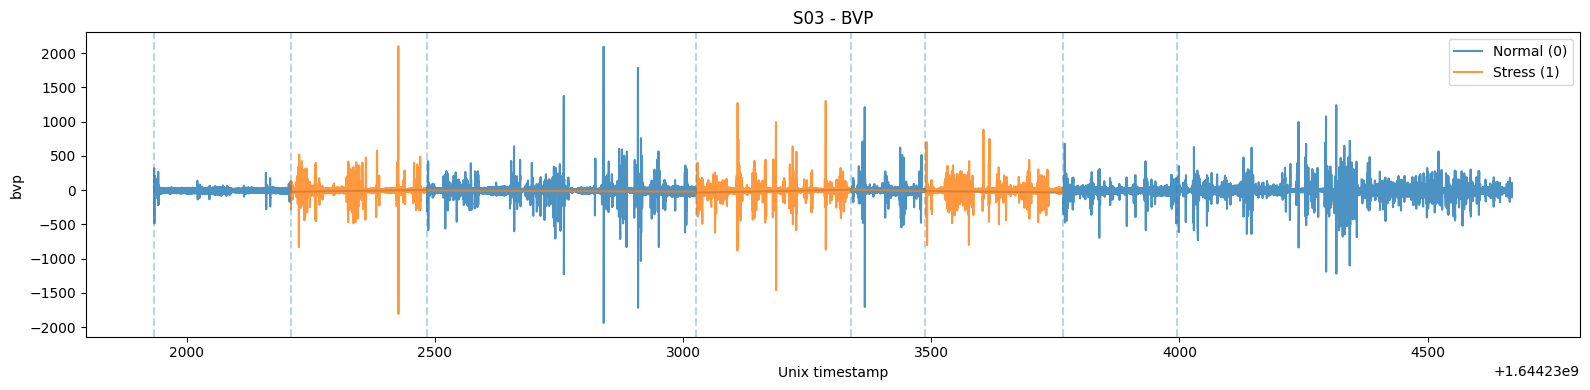

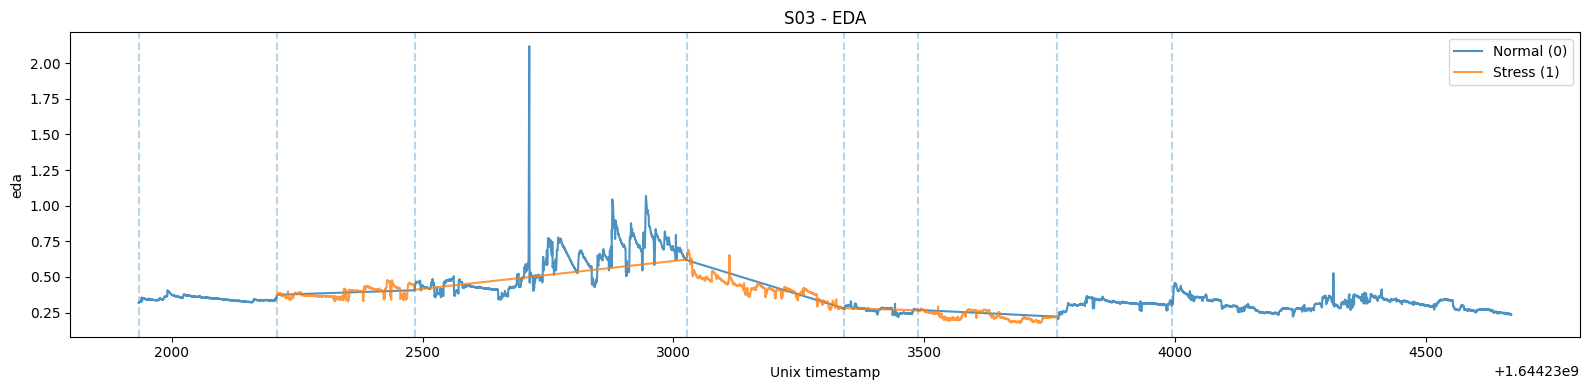

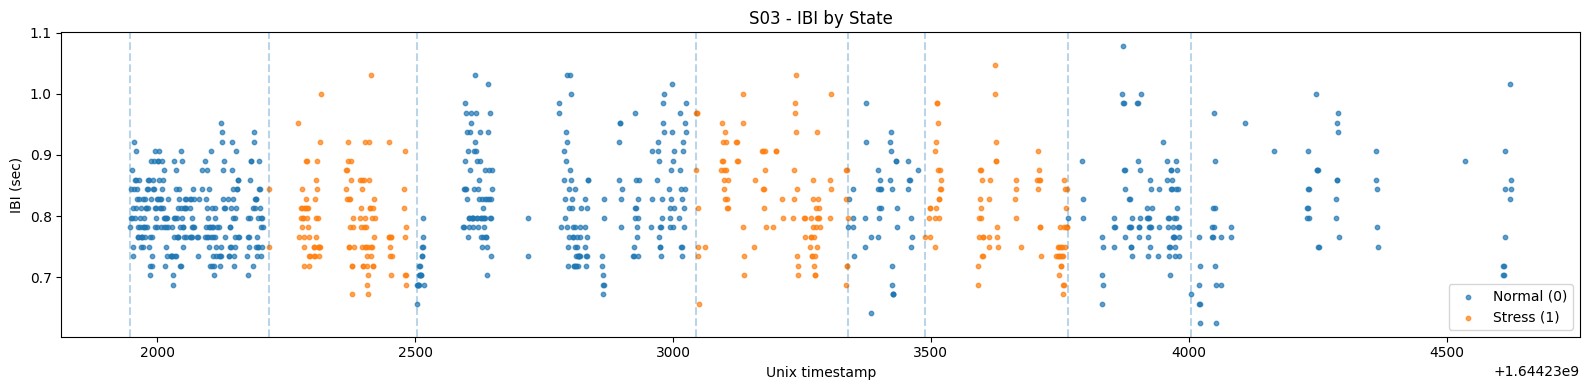


[S11] intervals
   interval_idx             phase             start               end  label  \
0             0          Baseline 1644852661.000000 1644853067.000000      0   
1             1            Stroop 1644853067.000000 1644853353.000000      1   
2             2             Rest1 1644853353.000000 1644853978.000000      0   
3             3              TSST 1644853978.000000 1644854293.000000      1   
4             4             Rest2 1644854293.000000 1644854446.000000      0   
5             5  Hyperventilation 1644854446.000000 1644854744.000000      1   

   duration_sec  
0    406.000000  
1    286.000000  
2    625.000000  
3    315.000000  
4    153.000000  
5    298.000000  


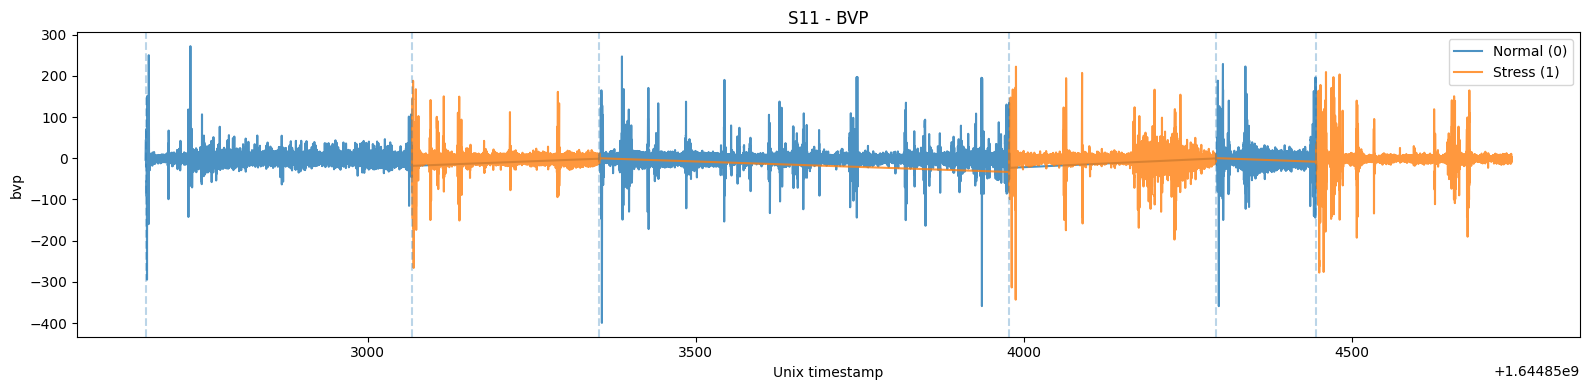

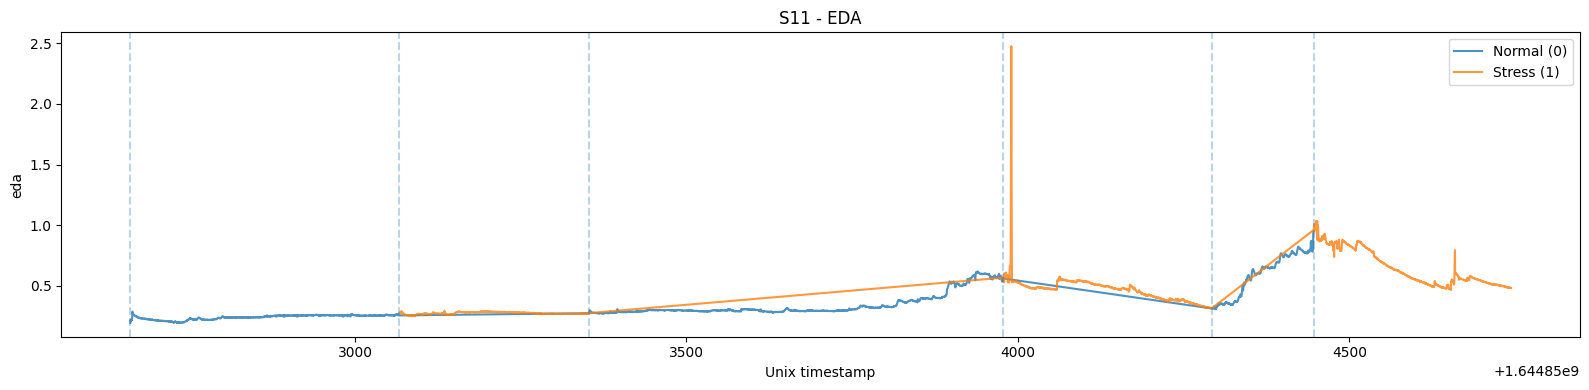

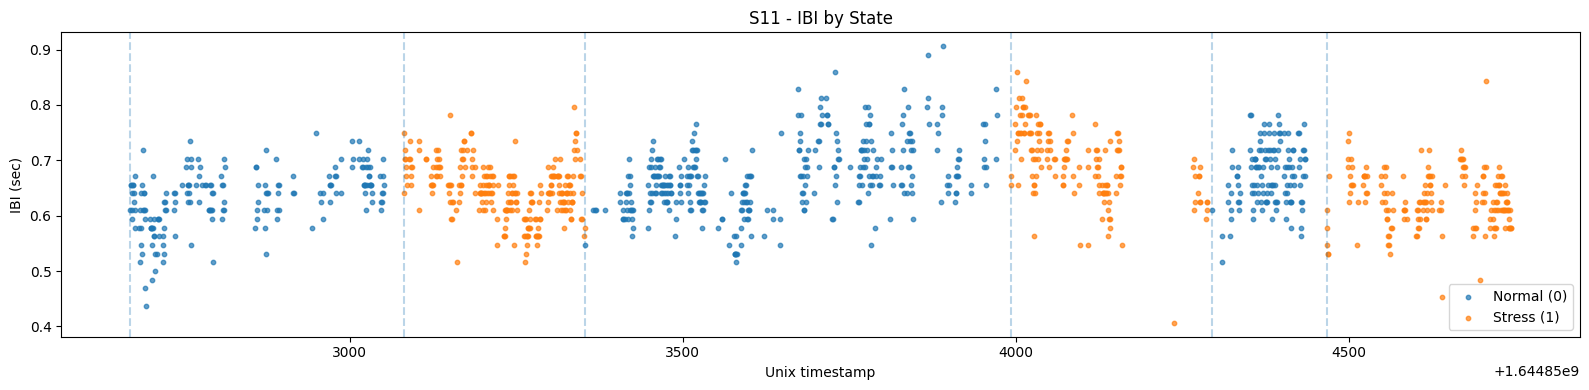


[S27] intervals
   interval_idx             phase             start               end  label  \
0             0          Baseline 1646647006.000000 1646647442.000000      0   
1             1            Stroop 1646647442.000000 1646647731.000000      1   
2             2             Rest1 1646647731.000000 1646648366.000000      0   
3             3              TSST 1646648366.000000 1646648644.000000      1   
4             4             Rest2 1646648644.000000 1646648761.000000      0   
5             5  Hyperventilation 1646648761.000000 1646649109.000000      1   

   duration_sec  
0    436.000000  
1    289.000000  
2    635.000000  
3    278.000000  
4    117.000000  
5    348.000000  


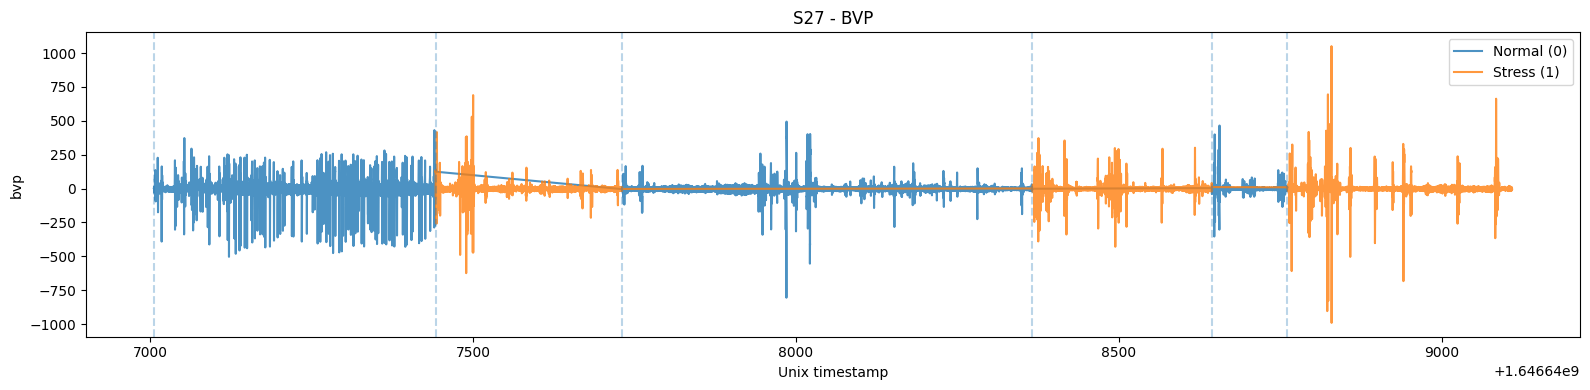

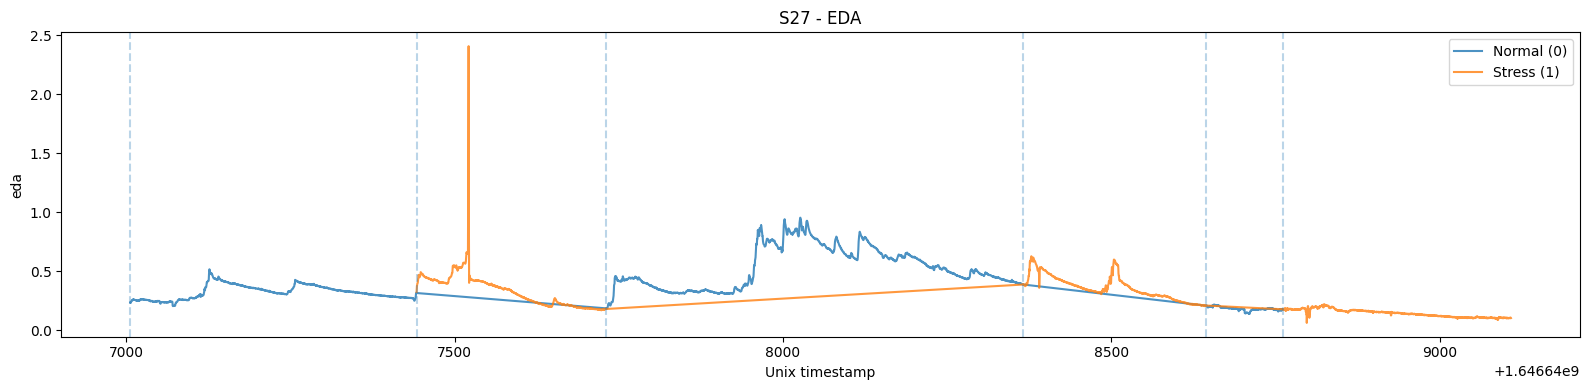

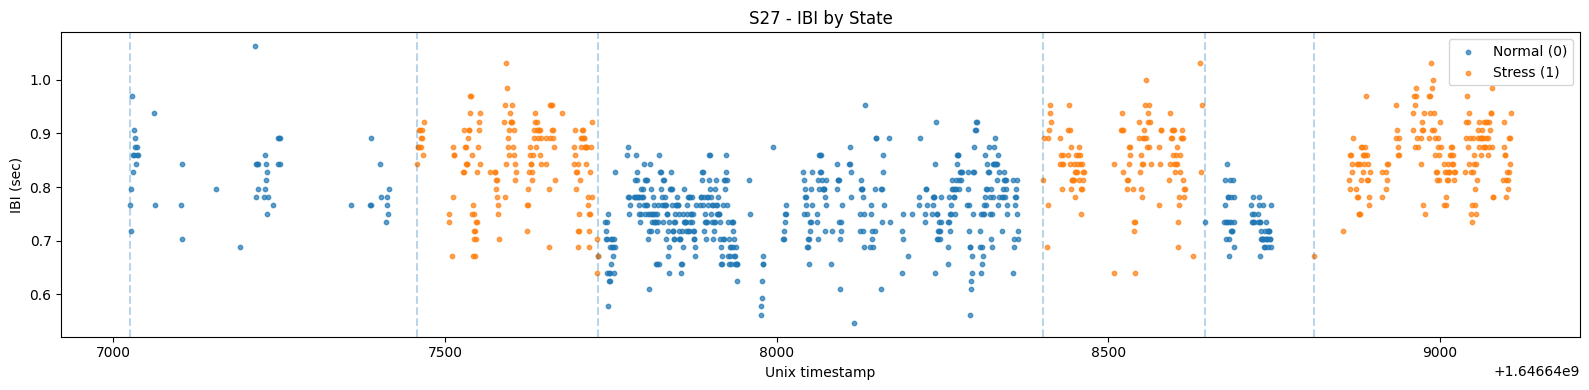


[S35] intervals
   interval_idx             phase             start               end  label  \
0             0          Baseline 1646839304.000000 1646839749.000000      0   
1             1            Stroop 1646839749.000000 1646840027.000000      1   
2             2             Rest1 1646840027.000000 1646840620.000000      0   
3             3              TSST 1646840620.000000 1646840935.000000      1   
4             4             Rest2 1646840935.000000 1646841040.000000      0   
5             5  Hyperventilation 1646841040.000000 1646841412.000000      1   

   duration_sec  
0    445.000000  
1    278.000000  
2    593.000000  
3    315.000000  
4    105.000000  
5    372.000000  


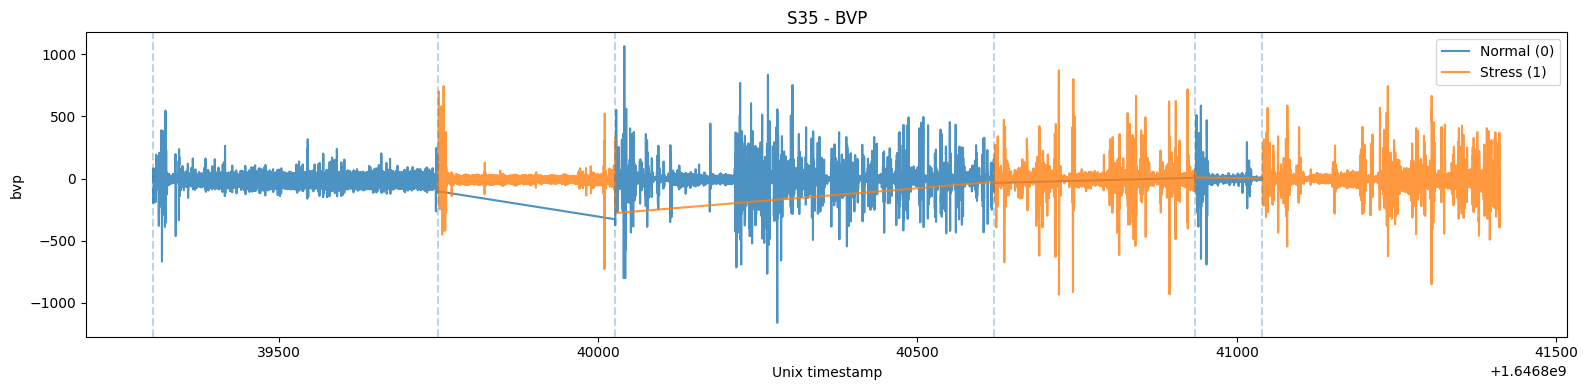

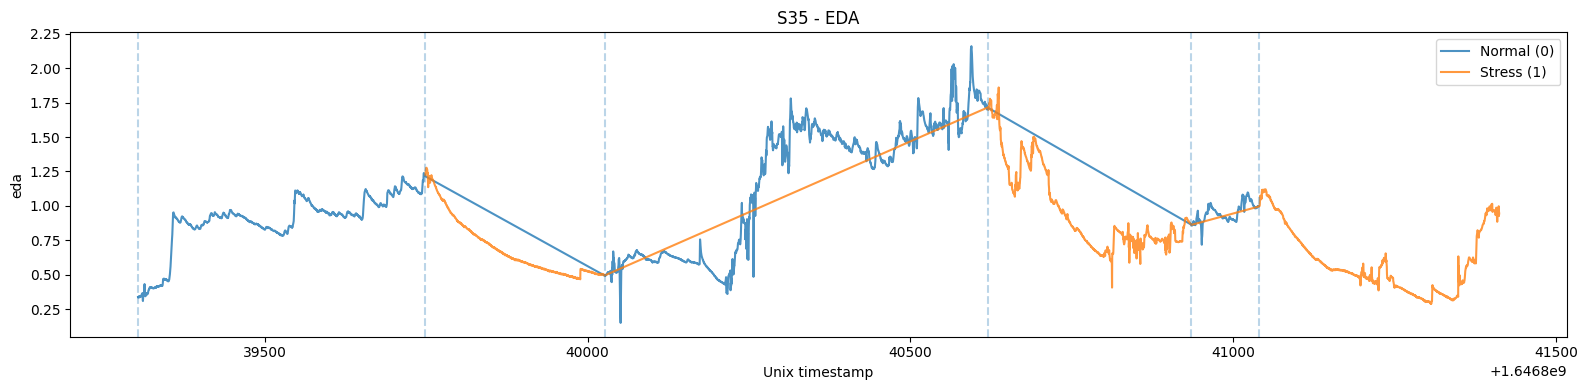

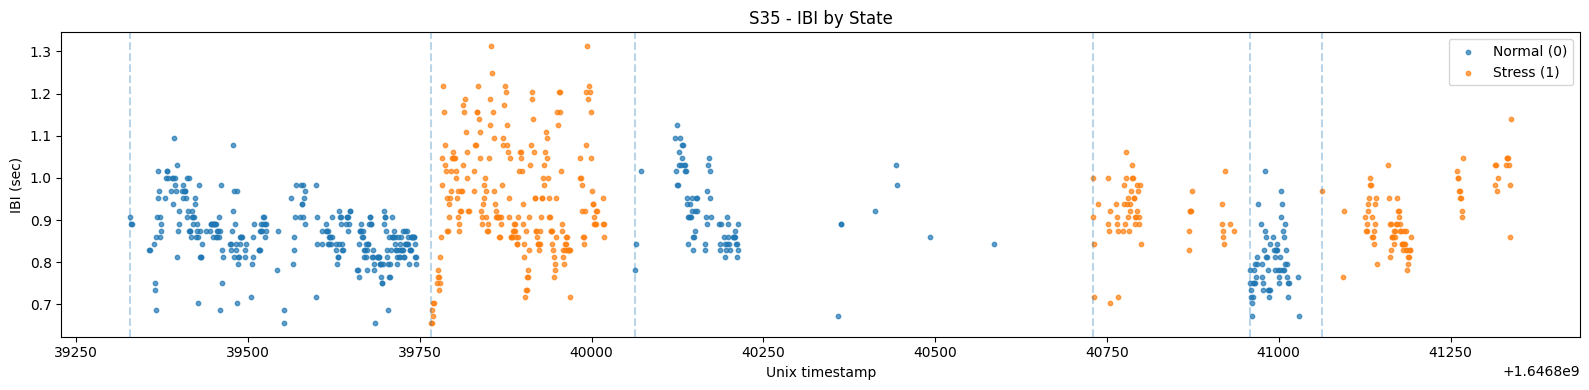

In [13]:
import matplotlib.pyplot as plt

# =========================================================
# tags -> protocol interval 생성
# =========================================================
def build_protocol_intervals(tags_df):
    """
    tags를 실험 프로토콜 순서에 맞춰 interval로 변환
    tag 개수가 부족하면 가능한 구간까지만 사용
    """

    timestamps = tags_df["timestamp"].values

    phase_info = [
        ("Baseline", 0),
        ("Stroop", 1),
        ("Rest1", 0),
        ("TSST", 1),
        ("Rest2", 0),
        ("Hyperventilation", 1),
        ("Rest3", 0),
        ("Questionnaire", 0),
        # 필요하면 tail도 넣을 수 있지만 보통 제외
    ]

    n_intervals_possible = len(timestamps) - 1
    n_use = min(n_intervals_possible, len(phase_info))

    if n_use <= 0:
        raise ValueError(f"유효한 interval을 만들 수 없음. tag 개수={len(timestamps)}")

    intervals = []
    for i in range(n_use):
        phase_name, label = phase_info[i]
        intervals.append({
            "interval_idx": i,
            "phase": phase_name,
            "start": timestamps[i],
            "end": timestamps[i + 1],
            "label": label
        })

    return pd.DataFrame(intervals)


# =========================================================
# signal dataframe에 phase / label 붙이기
# =========================================================
def assign_intervals_to_signal(signal_df, intervals_df, value_col):
    df = signal_df.copy()
    df["phase"] = None
    df["label"] = np.nan

    for _, row in intervals_df.iterrows():
        mask = (df["timestamp"] >= row["start"]) & (df["timestamp"] < row["end"])
        df.loc[mask, "phase"] = row["phase"]
        df.loc[mask, "label"] = row["label"]

    # protocol 밖 구간 제거
    df = df.dropna(subset=["label"]).copy()
    df["label"] = df["label"].astype(int)

    return df[["timestamp", value_col, "phase", "label"]]


# =========================================================
# line plot
# - normal / stress를 다른 색으로 표시
# =========================================================
def plot_signal_by_state(signal_df, value_col, subject_id, title=None):
    if title is None:
        title = f"{subject_id} - {value_col.upper()} by State"

    plt.figure(figsize=(16, 4))

    normal_df = signal_df[signal_df["label"] == 0]
    stress_df = signal_df[signal_df["label"] == 1]

    plt.plot(normal_df["timestamp"], normal_df[value_col], label="Normal (0)", alpha=0.8)
    plt.plot(stress_df["timestamp"], stress_df[value_col], label="Stress (1)", alpha=0.8)

    # phase 경계선
    phase_changes = signal_df["phase"].ne(signal_df["phase"].shift()).fillna(True)
    boundaries = signal_df.loc[phase_changes, "timestamp"].values
    for x in boundaries:
        plt.axvline(x=x, linestyle="--", alpha=0.3)

    plt.title(title)
    plt.xlabel("Unix timestamp")
    plt.ylabel(value_col)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# IBI는 scatter가 더 잘 보일 수 있어서 옵션 제공
# =========================================================
def plot_ibi_by_state(ibi_df, subject_id, scatter=True):
    plt.figure(figsize=(16, 4))

    normal_df = ibi_df[ibi_df["label"] == 0]
    stress_df = ibi_df[ibi_df["label"] == 1]

    if scatter:
        plt.scatter(normal_df["timestamp"], normal_df["ibi"], label="Normal (0)", s=10, alpha=0.7)
        plt.scatter(stress_df["timestamp"], stress_df["ibi"], label="Stress (1)", s=10, alpha=0.7)
    else:
        plt.plot(normal_df["timestamp"], normal_df["ibi"], label="Normal (0)", alpha=0.8)
        plt.plot(stress_df["timestamp"], stress_df["ibi"], label="Stress (1)", alpha=0.8)

    phase_changes = ibi_df["phase"].ne(ibi_df["phase"].shift()).fillna(True)
    boundaries = ibi_df.loc[phase_changes, "timestamp"].values
    for x in boundaries:
        plt.axvline(x=x, linestyle="--", alpha=0.3)

    plt.title(f"{subject_id} - IBI by State")
    plt.xlabel("Unix timestamp")
    plt.ylabel("IBI (sec)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# subject 하나 시각화
# =========================================================
def visualize_subject_states(all_data, subject_id="S01"):
    subj = all_data[subject_id]

    intervals_df = build_protocol_intervals(subj["tags"]).copy()
    intervals_df["duration_sec"] = intervals_df["end"] - intervals_df["start"]

    print(f"\n[{subject_id}] intervals")
    print(intervals_df)

    bvp_labeled = assign_intervals_to_signal(subj["bvp"], intervals_df, "bvp")
    eda_labeled = assign_intervals_to_signal(subj["eda"], intervals_df, "eda")
    ibi_labeled = assign_intervals_to_signal(subj["ibi"], intervals_df, "ibi")

    plot_signal_by_state(bvp_labeled, "bvp", subject_id, title=f"{subject_id} - BVP")
    plot_signal_by_state(eda_labeled, "eda", subject_id, title=f"{subject_id} - EDA")
    plot_ibi_by_state(ibi_labeled, subject_id, scatter=True)

    return intervals_df, bvp_labeled, eda_labeled, ibi_labeled


# =========================================================
# 실행 예시
# =========================================================
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
results = {}

for sid in ["S01", "S03", "S11", "S27", "S35"]:
    intervals, bvp, eda, ibi = visualize_subject_states(all_data, sid)

    results[sid] = {
        "intervals": intervals,
        "bvp": bvp,
        "eda": eda,
        "ibi": ibi
    }

In [16]:
def check_label_quality(all_data):
    summary = []

    for sid, subj in all_data.items():
        try:
            intervals = build_protocol_intervals(subj["tags"])

            bvp = assign_intervals_to_signal(subj["bvp"], intervals, "bvp")
            eda = assign_intervals_to_signal(subj["eda"], intervals, "eda")
            ibi = assign_intervals_to_signal(subj["ibi"], intervals, "ibi")

            for name, df in [("BVP", bvp), ("EDA", eda), ("IBI", ibi)]:
                total = len(df)
                n0 = (df["label"] == 0).sum()
                n1 = (df["label"] == 1).sum()
                n_nan = df["label"].isna().sum()

                summary.append({
                    "subject": sid,
                    "signal": name,
                    "total": total,
                    "normal(0)": n0,
                    "stress(1)": n1,
                    "nan": n_nan,
                    "ratio_stress": n1 / total if total > 0 else 0
                })

        except Exception as e:
            summary.append({
                "subject": sid,
                "signal": "ERROR",
                "total": 0,
                "normal(0)": 0,
                "stress(1)": 0,
                "nan": 0,
                "ratio_stress": 0,
                "error": str(e)
            })

    return pd.DataFrame(summary)

df_check = check_label_quality(all_data)
print(df_check)

    subject signal   total  normal(0)  stress(1)  nan  ratio_stress
0       S01    BVP  162816     100160      62656    0      0.384827
1       S01    EDA   10176       6260       3916    0      0.384827
2       S01    IBI    1204        752        452    0      0.375415
3       S02    BVP  187328     130944      56384    0      0.300991
4       S02    EDA   11708       8184       3524    0      0.300991
..      ...    ...     ...        ...        ...  ...           ...
100     S34    EDA    8000       4356       3644    0      0.455500
101     S34    IBI    2267       1241       1026    0      0.452581
102     S35    BVP  134912      73152      61760    0      0.457780
103     S35    EDA    8432       4572       3860    0      0.457780
104     S35    IBI     810        436        374    0      0.461728

[105 rows x 7 columns]


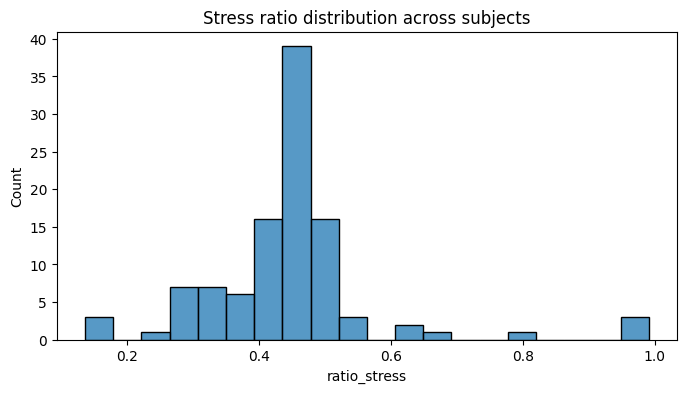

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df_check["ratio_stress"], bins=20)
plt.title("Stress ratio distribution across subjects")
plt.show()

In [19]:
def create_windows(df, window_size_sec=60, step_sec=60):
    windows = []

    start_time = df["timestamp"].min()
    end_time = df["timestamp"].max()

    t = start_time

    while t + window_size_sec <= end_time:
        window_df = df[(df["timestamp"] >= t) & (df["timestamp"] < t + window_size_sec)]

        if len(window_df) == 0:
            t += step_sec
            continue

        counts = window_df["label"].value_counts(normalize=True)

        major_label = counts.idxmax()
        major_ratio = counts.max()

        windows.append({
            "label": major_label,
            "major_ratio": major_ratio
        })

        t += step_sec

    return pd.DataFrame(windows)

def compute_window_counts(all_data, signal="eda", threshold=0.9):
    results = []

    for sid, subj in all_data.items():
        intervals = build_protocol_intervals(subj["tags"])
        df = assign_intervals_to_signal(subj[signal], intervals, signal)

        win_df = create_windows(df)

        # quality filtering
        win_df = win_df[win_df["major_ratio"] >= threshold]

        n0 = (win_df["label"] == 0).sum()
        n1 = (win_df["label"] == 1).sum()

        results.append({
            "subject": sid,
            "normal": n0,
            "stress": n1,
            "total": n0 + n1
        })

    return pd.DataFrame(results)

df_counts = compute_window_counts(all_data, signal="eda", threshold=0.9)

print(df_counts)

   subject  normal  stress  total
0      S01      22      15     37
1      S02      32      12     44
2      S03      27      12     39
3      S04      30      12     42
4      S05      16      12     28
5      S06      16      17     33
6      S07      16      12     28
7      S08      15      12     27
8      S09      14      14     28
9      S10      15      14     29
10     S11      17      13     30
11     S12      16      13     29
12     S13      17      12     29
13     S14      17      12     29
14     S15      16      14     30
15     S16      14      15     29
16     S17       1      39     40
17     S18      29      14     43
18     S19      14      15     29
19     S20      15      13     28
20     S21      17      13     30
21     S22      17      13     30
22     S23      15      13     28
23     S24      15      13     28
24     S25      16      13     29
25     S26      16      12     28
26     S27      18      13     31
27     S28      18      13     31
28     S29    

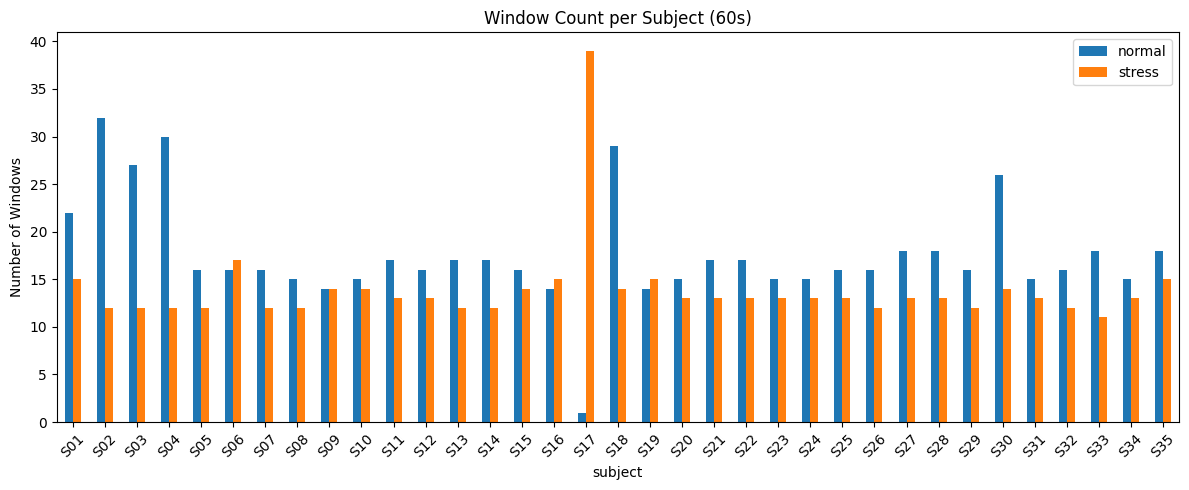

In [20]:
import matplotlib.pyplot as plt

df_counts.set_index("subject")[["normal", "stress"]].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Window Count per Subject (60s)")
plt.ylabel("Number of Windows")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

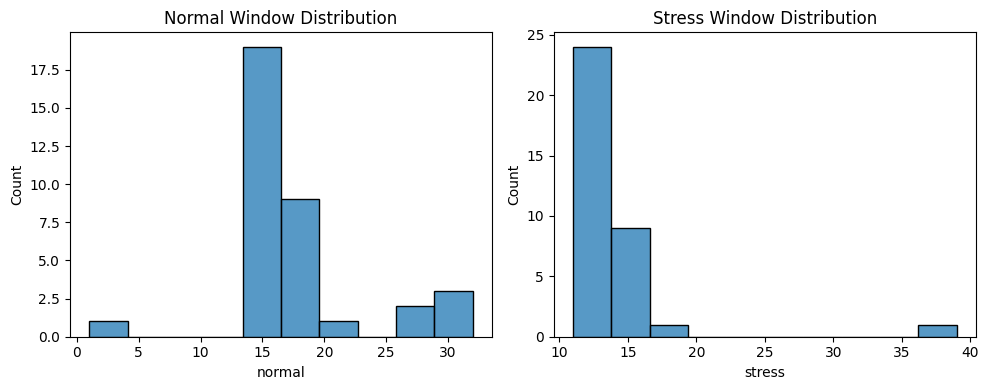

In [21]:
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_counts["normal"], bins=10)
plt.title("Normal Window Distribution")

plt.subplot(1,2,2)
sns.histplot(df_counts["stress"], bins=10)
plt.title("Stress Window Distribution")

plt.tight_layout()
plt.show()

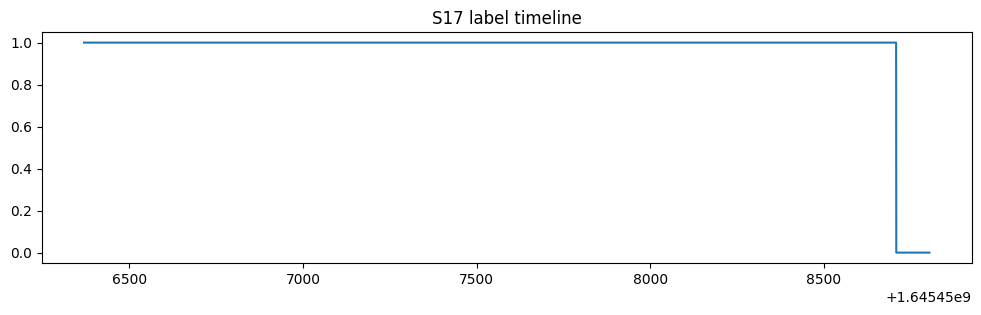

In [22]:
subj = all_data["S17"]

intervals = build_protocol_intervals(subj["tags"])
df = assign_intervals_to_signal(subj["eda"], intervals, "eda")

df["label"].value_counts()

plt.figure(figsize=(12,3))
plt.plot(df["timestamp"], df["label"])
plt.title("S17 label timeline")
plt.show()